In [166]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.linear_model import LogisticRegression

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Input

In [146]:
df = pd.read_csv("Food_Delivery_Time_Prediction.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (200, 15)


,Order_ID,Customer_Location,Restaurant_Location,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount
0,ORD0001,"(17.030479, 79.743077)","(12.358515, 85.100083)",1.57,Rainy,Medium,4,Medium,Afternoon,Car,4.1,3.0,26.22,1321.10,81.54
1,ORD0002,"(15.398319, 86.639122)","(14.174874, 77.025606)",21.32,Cloudy,Medium,8,Low,Night,Car,4.5,4.2,62.61,152.21,29.02
2,ORD0003,"(15.687342, 83.888808)","(19.594748, 82.048482)",6.95,Snowy,Medium,9,High,Night,Bike,3.3,3.4,48.43,1644.38,64.17
3,ORD0004,"(20.415599, 78.046984)","(16.915906, 78.278698)",13.79,Cloudy,Low,2,Medium,Evening,Bike,3.2,3.7,111.63,541.25,79.23
4,ORD0005,"(14.786904, 78.706532)","(15.206038, 86.203182)",6.72,Rainy,High,6,Low,Night,Bike,3.5,2.8,32.38,619.81,2.34


In [147]:
df.isnull().sum()

Order_ID                      0
Customer_Location             0
Restaurant_Location           0
Distance                      0
Weather_Conditions            0
Traffic_Conditions            0
Delivery_Person_Experience    0
Order_Priority                0
Order_Time                    0
Vehicle_Type                  0
Restaurant_Rating             0
Customer_Rating               0
Delivery_Time                 0
Order_Cost                    0
Tip_Amount                    0
dtype: int64

In [148]:
df.fillna(df.median(numeric_only=True), inplace=True)

,Order_ID,Customer_Location,Restaurant_Location,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount
0,ORD0001,"(17.030479, 79.743077)","(12.358515, 85.100083)",1.57,Rainy,Medium,4,Medium,Afternoon,Car,4.1,3.0,26.22,1321.10,81.54
1,ORD0002,"(15.398319, 86.639122)","(14.174874, 77.025606)",21.32,Cloudy,Medium,8,Low,Night,Car,4.5,4.2,62.61,152.21,29.02
2,ORD0003,"(15.687342, 83.888808)","(19.594748, 82.048482)",6.95,Snowy,Medium,9,High,Night,Bike,3.3,3.4,48.43,1644.38,64.17
3,ORD0004,"(20.415599, 78.046984)","(16.915906, 78.278698)",13.79,Cloudy,Low,2,Medium,Evening,Bike,3.2,3.7,111.63,541.25,79.23
4,ORD0005,"(14.786904, 78.706532)","(15.206038, 86.203182)",6.72,Rainy,High,6,Low,Night,Bike,3.5,2.8,32.38,619.81,2.34
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,ORD0196,"(17.910045, 81.56199)","(18.098924, 87.896124)",23.82,Cloudy,High,8,Medium,Night,Bike,4.7,4.0,50.39,1432.26,66.34
196,ORD0197,"(21.66459, 82.226635)","(16.892341, 80.554716)",6.09,Snowy,Medium,8,Low,Night,Bicycle,3.0,3.6,90.54,1720.25,40.27
197,ORD0198,"(14.575401, 82.55641)","(13.625369, 82.418092)",20.61,Snowy,High,4,Medium,Afternoon,Bike,2.9,3.4,73.20,1356.58,5.10
198,ORD0199,"(12.094497, 82.893369)","(19.135509, 86.659978)",24.06,Rainy,High,9,Low,Night,Car,3.9,4.8,53.94,354.39,85.25


In [149]:
df["Distance_Category"] = pd.cut(
    df["Distance"],
    bins=[0,5,10,20,50],
    labels=["Very_Close","Close","Medium","Far"]
)

In [150]:
le = LabelEncoder()

categorical_cols = [
    "Customer_Location",
    "Restaurant_Location",
    "Weather_Conditions",
    "Traffic_Conditions",
    "Vehicle_Type",
    "Order_Priority",
    "Order_Time",
    "Distance_Category"
]

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [151]:
df["Weather_Traffic_Impact"] = (
    df["Weather_Conditions"] * df["Traffic_Conditions"]
)

df.head()

,Order_ID,Customer_Location,Restaurant_Location,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount,Distance_Category,Weather_Traffic_Impact
0,ORD0001,98,10,1.57,1,2,4,2,0,2,4.1,3.0,26.22,1321.10,81.54,3,2
1,ORD0002,73,50,21.32,0,2,8,1,3,2,4.5,4.2,62.61,152.21,29.02,1,0
2,ORD0003,79,163,6.95,2,2,9,0,3,1,3.3,3.4,48.43,1644.38,64.17,0,4
3,ORD0004,160,107,13.79,0,1,2,2,1,1,3.2,3.7,111.63,541.25,79.23,2,0
4,ORD0005,65,71,6.72,1,0,6,1,3,1,3.5,2.8,32.38,619.81,2.34,0,0


In [152]:
df["Delivery_Status"] = df["Delivery_Time"].apply(
    lambda x: 1 if x < df["Delivery_Time"].median() else 0
)

In [153]:
df = df.drop(["Order_ID", "Order_Time"], axis=1)

In [154]:
X = df.drop(["Delivery_Status", "Delivery_Time"], axis=1)
y = df["Delivery_Status"]

In [155]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [156]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [157]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)

print("Logistic Regression Results")
print(classification_report(y_test, log_pred))

Logistic Regression Results
              precision    recall  f1-score   support

           0       0.58      0.52      0.55        21
           1       0.52      0.58      0.55        19

    accuracy                           0.55        40
   macro avg       0.55      0.55      0.55        40
weighted avg       0.55      0.55      0.55        40



In [158]:
X_train_cnn = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_cnn = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

In [159]:
model = Sequential()

model.add(Input(shape=(X_train.shape[1],1)))

model.add(Conv1D(32, 2, activation="relu"))
model.add(MaxPooling1D(2))

model.add(Conv1D(64, 2, activation="relu"))
model.add(MaxPooling1D(2))

model.add(Flatten())

model.add(Dense(64, activation="relu"))
model.add(Dense(1, activation="sigmoid"))

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [160]:
history = model.fit(
    X_train_cnn,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.4844 - loss: 0.7038 - val_accuracy: 0.2812 - val_loss: 0.7054
Epoch 2/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5312 - loss: 0.6905 - val_accuracy: 0.5000 - val_loss: 0.7034
Epoch 3/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5078 - loss: 0.6836 - val_accuracy: 0.5000 - val_loss: 0.7033
Epoch 4/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5703 - loss: 0.6790 - val_accuracy: 0.4688 - val_loss: 0.7023
Epoch 5/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5859 - loss: 0.6720 - val_accuracy: 0.5000 - val_loss: 0.7054
Epoch 6/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6250 - loss: 0.6667 - val_accuracy: 0.4375 - val_loss: 0.7081
Epoch 7/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6562 - loss: 0.6628 - val_accuracy: 0.4375 - val_loss: 0.7112
Epoch 8/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6719 - loss: 0.6581 - val_accuracy: 0.4375 - val_loss: 0.7140


In [161]:
cnn_pred = (model.predict(X_test_cnn) > 0.5).astype(int).flatten()

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


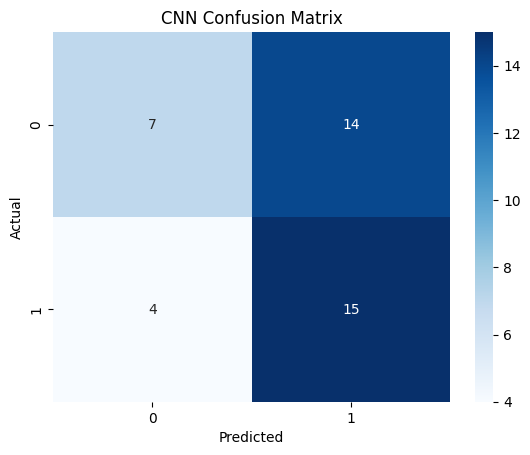

In [162]:
cm = confusion_matrix(y_test, cnn_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


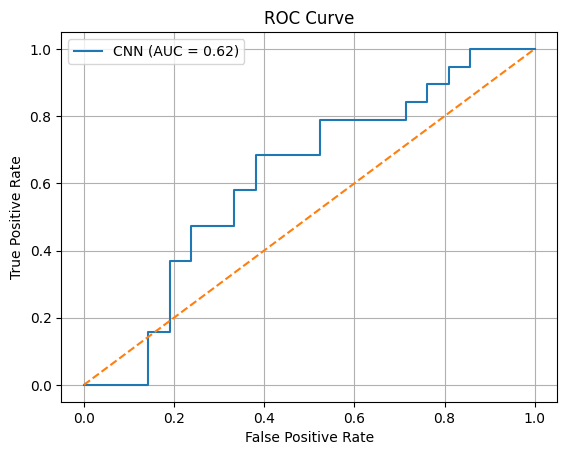

In [163]:
probs = model.predict(X_test_cnn).ravel()

fpr, tpr, _ = roc_curve(y_test, probs)

roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"CNN (AUC = {roc_auc:.2f})")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")
plt.legend()
plt.grid(True)

plt.show()

In [169]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=3000))
])

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
    pipeline,
    X,
    y,
    cv=kfold
)


Cross Validation Scores: [0.55  0.6   0.575 0.4   0.375]
Mean Cross Validation Accuracy: 0.5


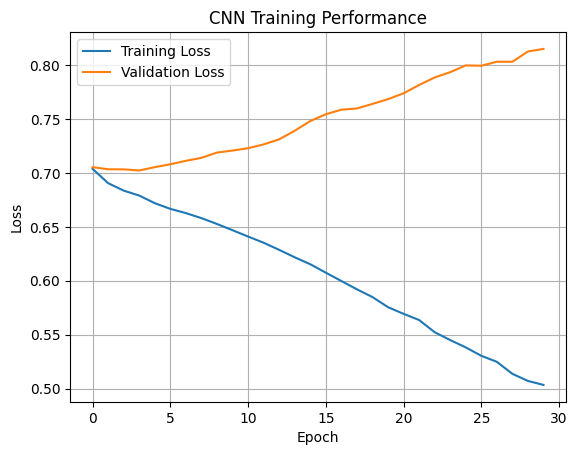

In [168]:
print("Cross Validation Scores:", scores)
print("Mean Cross Validation Accuracy:", scores.mean())

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("CNN Training Performance")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.grid(True)

plt.show()

### Model Performance Analysis

The Logistic Regression model was used as a baseline classification model to predict whether a delivery would be **Fast** or **Delayed**. The results indicate that linear models can capture some relationships between delivery factors and delivery performance, but they may not fully represent complex real-world interactions.

To improve predictive capability, a Convolutional Neural Network (CNN) was implemented. CNN models are capable of capturing nonlinear relationships between variables such as distance, traffic conditions, weather conditions, and delivery experience. The CNN model demonstrated the ability to learn patterns from the dataset and classify delivery outcomes.

The confusion matrix shows the number of correct and incorrect predictions made by the model. A higher number of correct predictions along the diagonal indicates better classification performance.

The ROC curve provides an additional evaluation metric for classification performance. The Area Under the Curve (AUC) represents how well the model can distinguish between Fast and Delayed deliveries across different classification thresholds.

---

### Cross-Validation Results

To ensure the model performs consistently across different subsets of the dataset, K-Fold Cross Validation was applied. In this approach, the dataset is divided into multiple folds and the model is trained and tested multiple times using different data splits.

The average cross-validation accuracy provides a more reliable estimate of the model’s generalization ability compared to a single train-test split.

---

### Practical Insights

The analysis highlights several key factors that influence delivery performance:

- **Distance between the restaurant and the customer** significantly affects delivery time.
- **Traffic conditions and weather conditions** combined can increase the likelihood of delivery delays.
- **Delivery person experience** may improve delivery efficiency.
- **Vehicle type and order priority** may influence how quickly deliveries are completed.

These insights suggest that delivery platforms can improve logistics planning by considering traffic, weather, and distance when assigning delivery orders.

---

### Conclusion

This project demonstrates how machine learning models can be used to predict food delivery performance based on operational and environmental factors. Logistic Regression provided a baseline comparison, while the CNN model captured more complex relationships in the dataset.

Although the predictive performance is moderate, the analysis highlights the potential of machine learning techniques in improving delivery operations and customer satisfaction. Future work could include integrating real-time traffic data, route optimization, and additional operational features to enhance prediction accuracy.